In [1]:
import numpy as np
wave, flux = np.loadtxt("default_sed1.dat", unpack=True)  # Update path as needed


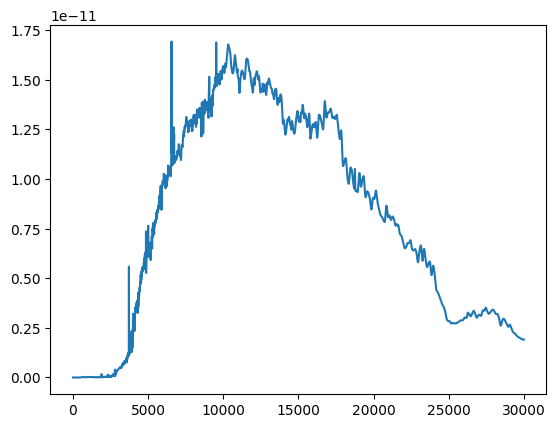

In [2]:
import matplotlib.pyplot as plt
plt.plot(wave,flux)


In [3]:
from sedpy.observate import load_filters, getSED
filters = load_filters(['hsc_g', 'hsc_r', 'hsc_i', 'hsc_z', 'hsc_y'])

C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sedpy\observate.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename, resource_listdir


In [4]:
# Save each filter as a .dat file
for f in filters:
    # Each filter object has a .wavelength (Å) and .transmission attribute
    data = np.column_stack([f.wavelength, f.transmission])
    np.savetxt(f"{f.name}.dat", data, fmt="%.6e", header="wavelength(Angstrom) transmission", comments="")

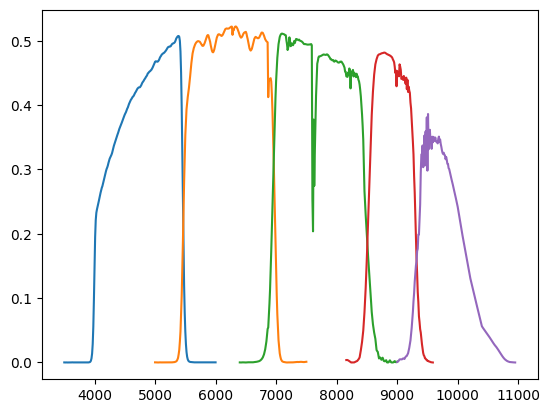

In [5]:
for i in filters:
    plt.plot(i.wavelength, i.transmission)

In [8]:
redshift=np.linspace(0,5,1000)
phot={}
for i in redshift:
    phot[i]=getSED(wave*(1+i),flux/((1+i)**2),filters,linear_flux=True)

In [124]:
fn=[f.name for f in filters]
phot_df=pd.DataFrame(phot,index=fn)

In [125]:
phot_df

,0.000000,0.005005,0.010010,0.015015,0.020020,0.025025,0.030030,0.035035,0.040040,0.045045,...,4.954955,4.959960,4.964965,4.969970,4.974975,4.979980,4.984985,4.989990,4.994995,5.000000
hsc_g,7.279577,7.305860,7.332210,7.358816,7.385711,7.412627,7.439597,7.466047,7.492135,7.518117,...,17.734328,17.734982,17.735536,17.736003,17.736395,17.736726,17.736989,17.737209,17.737398,17.737573
hsc_r,6.111243,6.129308,6.147226,6.165303,6.183458,6.201727,6.220027,6.239114,6.258770,6.279034,...,16.550667,16.552610,16.554638,16.556750,16.558947,16.561231,16.563597,16.566036,16.568547,16.571129
hsc_i,5.418408,5.434011,5.449686,5.464697,5.479902,5.495197,5.509570,5.523908,5.538392,5.552100,...,16.415486,16.415976,16.416362,16.416629,16.416792,16.416886,16.416899,16.416818,16.416675,16.416462
hsc_z,5.006327,5.020507,5.033108,5.045314,5.058268,5.071857,5.085351,5.098482,5.111775,5.125086,...,16.447927,16.446021,16.444129,16.442267,16.440433,16.438618,16.436855,16.435164,16.433658,16.432123
hsc_y,4.683780,4.701122,4.719282,4.736665,4.755043,4.772208,4.789571,4.806742,4.823365,4.840477,...,16.348011,16.351186,16.354359,16.357499,16.360672,16.363866,16.367066,16.370315,16.373595,16.376929


In [126]:
colour = {}
for i in range(len(fn) - 1):  # stop at second last index
    f1 = fn[i]
    f2 = fn[i + 1]
    
    # Optionally skip if f2 is not in fn (though this is guaranteed here)
    if f2 not in fn:
        continue
    
    # Define color key based on last character (band)
    color_key = f"{f1[-1]}-{f2[-1]}"
    
    # Compute color: mag[f1] - mag[f2]
    colour[color_key] = phot_df.loc[f1] - phot_df.loc[f2]

In [127]:
color_df=pd.DataFrame(colour)

In [128]:
color_df

,g-r,r-i,i-z,z-y
0.000000,1.168334,0.692835,0.412080,0.322548
0.005005,1.176552,0.695297,0.413505,0.319384
0.010010,1.184984,0.697540,0.416578,0.313827
0.015015,1.193513,0.700605,0.419384,0.308648
0.020020,1.202253,0.703556,0.421634,0.303225
...,...,...,...,...
4.979980,1.175495,0.144345,-0.021733,0.074752
4.984985,1.173392,0.146698,-0.019956,0.069789
4.989990,1.171173,0.149218,-0.018347,0.064850
4.994995,1.168851,0.151872,-0.016983,0.060063


In [129]:
# This is the prior HDFN prior from Benitez 2000, adapted from the BPZ code.
# This could be replaced with any redshift, magnitude, and type distribution.
def bpz_prior(z, m, nt):
    nz = len(z)
    momin_hdf = 20.
    if m>32.: m = 32.
    if m<20.: m = 20.    
    # nt Templates = nell Elliptical + nsp Spiral + nSB starburst
      # nt is a list of 3 values
    nell, nsp, nsb = nt
    nn = nell, nsp, nsb
    nt = sum(nn)
    # See Table 1 of Benitez00
    a  = 2.465,  1.806,  0.906
    zo = 0.431,  0.390,  0.0626
    km = 0.0913, 0.0636, 0.123
    k_t= 0.450,  0.147
    a  = np.repeat(a, nn)
    zo = np.repeat(zo, nn)
    km = np.repeat(km, nn)
    k_t= np.repeat(k_t, nn[:2])
    # Fractions expected at m = 20: 35% E/S0, 50% Spiral, 15% Irr
    fo_t = 0.35, 0.5
    fo_t = fo_t / np.array(nn[:2])
    fo_t = np.repeat(fo_t, nn[:2])
    dm = m-momin_hdf
    zmt = np.clip(zo+km*dm,0.01,15.)
    zmt_at_a = zmt**(a)
    zt_at_a = np.power.outer(z,a)
    #Morphological fractions
    nellsp = nell + nsp
    f_t = np.zeros((len(a),),float)
    f_t[:nellsp] = fo_t*np.exp(-k_t*dm)
    f_t[nellsp:] = (1.-np.add.reduce(f_t[:nellsp]))/float(nsb)
    #Formula: zm=zo+km*(m_m_min)  and  p(z|T,m)=(z**a)*exp(-(z/zm)**a)
    p_i = zt_at_a[:nz,:nt]*np.exp(-np.clip(zt_at_a[:nz,:nt]/zmt_at_a[:nt],0.,700.))
    #This eliminates the very low level tails of the priors
    norm = np.add.reduce(p_i[:nz,:nt],0)
    p_i[:nz,:nt] = np.where(np.less(p_i[:nz,:nt]/norm[:nt],1e-2/float(nz)),
              0.,p_i[:nz,:nt]/norm[:nt])
    norm = np.add.reduce(p_i[:nz,:nt],0)
    p_i[:nz,:nt] = p_i[:nz,:nt]/norm[:nt]*f_t[:nt]
    return p_i

C:\Users\pranav\AppData\Local\Temp\ipykernel_23284\65054345.py:24: RuntimeWarning: divide by zero encountered in divide
  fo_t = fo_t / np.array(nn[:2])


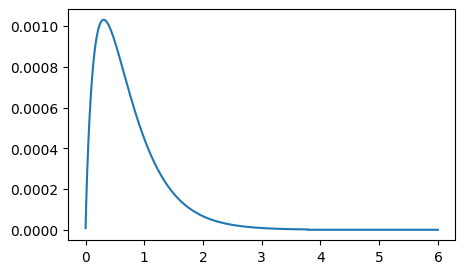

In [130]:
# This is the "fine" redshift grid we will use
z_grid_binsize = 0.001
z_grid_edges = np.arange(0.0, 6.0, z_grid_binsize)
z_grid = (z_grid_edges[1:] + z_grid_edges[:-1])/2.

# Just some boolean indexing of templates used. Needed later for some BPZ fcts.
#selectedtemplates = np.repeat(False, 1)

# Using all templates
templatetypesnb = (0,0,1) # nb of ellipticals, spirals, and starburst used in the 8-template library.
#selectedtemplates[:] = True

# Uncomment that to use three templates using
#templatetypesnb = (1,1,1) #(1,2,8-3) 
#selectedtemplates[0:1] = True
nt = sum(templatetypesnb)


# Use the p(z,t,m) distribution defined above
m = 22.0 # some reference magnitude
redshift_model = bpz_prior(z_grid, m, templatetypesnb)



# Plot the priors for these templates
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
p = ax.plot(z_grid, redshift_model)


In [144]:
pz=redshift_model.flatten()
N_samples = 10000
z_samples = np.random.choice(z_grid, size=N_samples, p=pz)
z_samples.sort()

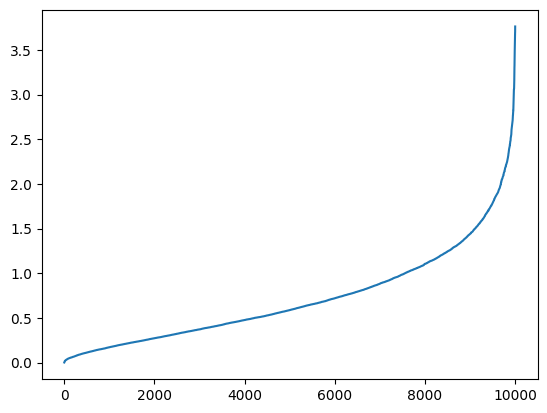

In [158]:
plt.plot(z_samples)

In [146]:
phot_s={}
for i in z_samples:
    phot_s[i]=getSED(wave*(1+i),flux/((1+i)**2),filters)

In [147]:
import pandas as pd
fn=[f.name for f in filters]
phot_s_df=pd.DataFrame(phot_s,index=fn)
phot_s_df

,0.0015,0.0025,0.0035,0.0045,0.0055,0.0095,0.0125,0.0155,0.0175,0.0185,...,3.5265,3.5315,3.5925,3.6445,3.6715,3.6745,3.6835,3.6955,3.6985,3.7625
hsc_g,7.287428,7.292678,7.297930,7.303188,7.308451,7.329530,7.345391,7.361435,7.372167,7.377536,...,16.602787,16.603976,16.625042,16.645578,16.656508,16.657923,16.662418,16.668976,16.670707,16.712237
hsc_r,6.116684,6.120304,6.123912,6.127540,6.131177,6.145389,6.156211,6.166971,6.174227,6.177898,...,16.386673,16.386819,16.389538,16.395654,16.399467,16.399810,16.400852,16.402021,16.402284,16.405658
hsc_i,5.423155,5.426197,5.429169,5.432134,5.435323,5.448007,5.457142,5.466384,5.472176,5.475227,...,16.248473,16.255338,16.304339,16.320036,16.330268,16.331446,16.333929,16.338045,16.339486,16.361308
hsc_z,5.010761,5.013620,5.016339,5.019020,5.021597,5.031896,5.039105,5.046698,5.051679,5.054177,...,15.349958,15.355197,15.428437,15.493138,15.528612,15.532865,15.545955,15.567263,15.572492,15.642896
hsc_y,4.689059,4.692259,4.696207,4.699601,4.702882,4.717212,4.727946,4.738241,4.745882,4.749248,...,14.736792,14.744855,14.852292,14.952738,15.004208,15.009673,15.026758,15.049033,15.054232,15.169463


In [148]:
def imag_err(m, mlim):
    a, b = 4.56, 1
    k = 1
    sigmadet = 5
    teff = np.exp(a + b * (mlim - 21.))
    F = 10**(-0.4*(m-22.5))
    Flim = 10**(-0.4*(mlim-22.5))
    Fnoise = (Flim/sigmadet)**2 * k * teff - Flim
    return 2.5/np.log(10) * np.sqrt( (1 + Fnoise/F) / (F*k*teff))

maglim = 24
mag_errors = {}

for z, mags in phot_s.items():
    mags = np.array(mags)  # convert list to array
    errs = imag_err(mags, maglim)  # apply imag_err element-wise
    mag_errors[z] = errs

In [149]:
phot_noisy = {}

for z in phot_s:
    mags = np.array(phot_s[z])
    errs = mag_errors[z]
    noisy = mags + np.random.normal(0, errs)
    phot_noisy[z] = noisy

In [150]:
phot_noisy_df=pd.DataFrame(phot_noisy,index=fn)
phot_noisy_df

,0.0015,0.0025,0.0035,0.0045,0.0055,0.0095,0.0125,0.0155,0.0175,0.0185,...,3.5265,3.5315,3.5925,3.6445,3.6715,3.6745,3.6835,3.6955,3.6985,3.7625
hsc_g,7.287462,7.292678,7.297983,7.303204,7.308455,7.329519,7.345400,7.361409,7.372165,7.377528,...,16.603624,16.602747,16.623395,16.646029,16.655423,16.657181,16.660771,16.666873,16.672077,16.711482
hsc_r,6.116709,6.120307,6.123911,6.127554,6.131163,6.145392,6.156208,6.166970,6.174244,6.177900,...,16.384225,16.387925,16.388243,16.396593,16.401042,16.399010,16.400672,16.398054,16.399321,16.404835
hsc_i,5.423158,5.426210,5.429189,5.432122,5.435327,5.448009,5.457160,5.466385,5.472159,5.475248,...,16.248340,16.251854,16.305645,16.318783,16.332050,16.332515,16.331591,16.338279,16.341211,16.360290
hsc_z,5.010753,5.013622,5.016330,5.019025,5.021598,5.031901,5.039102,5.046699,5.051670,5.054180,...,15.349609,15.355309,15.429214,15.493024,15.528690,15.530483,15.545942,15.567245,15.573676,15.643641
hsc_y,4.689056,4.692243,4.696207,4.699600,4.702886,4.717210,4.727948,4.738240,4.745885,4.749259,...,14.736470,14.745089,14.853965,14.953272,15.003925,15.009605,15.025881,15.050131,15.053616,15.169930


In [151]:
colour_noisy = {}
for i in range(len(fn) - 1):  # stop at second last index
    f1 = fn[i]
    f2 = fn[i + 1]
    
    # Optionally skip if f2 is not in fn (though this is guaranteed here)
    if f2 not in fn:
        continue
    
    # Define color key based on last character (band)
    color_key = f"{f1[-1]}-{f2[-1]}"
    
    # Compute color: mag[f1] - mag[f2]
    colour_noisy[color_key] = phot_noisy_df.loc[f1] - phot_noisy_df.loc[f2]

In [152]:
color_noisy_df=pd.DataFrame(colour_noisy)
color_noisy_df

,g-r,r-i,i-z,z-y
0.0015,1.170754,0.693550,0.412405,0.321697
0.0025,1.172372,0.694097,0.412588,0.321378
0.0035,1.174072,0.694722,0.412859,0.320123
0.0045,1.175650,0.695432,0.413097,0.319425
0.0055,1.177292,0.695836,0.413729,0.318712
...,...,...,...,...
3.6745,0.258172,0.066495,0.802032,0.520877
3.6835,0.260098,0.069081,0.785649,0.520061
3.6955,0.268819,0.059776,0.771034,0.517114
3.6985,0.272756,0.058110,0.767535,0.520060


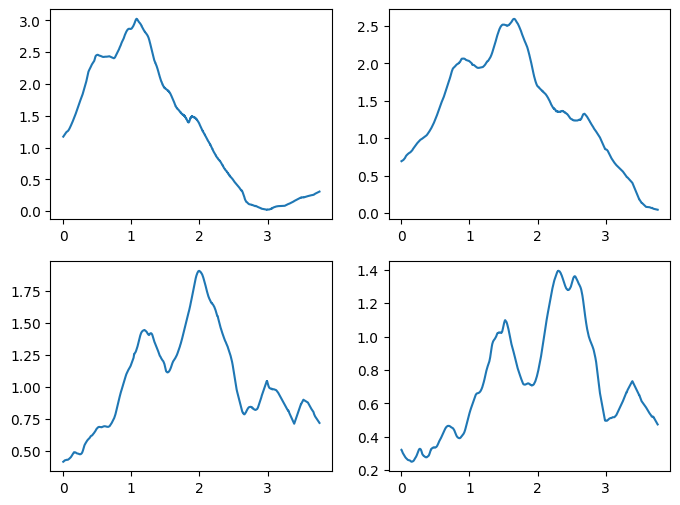

In [153]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6))

ax[0, 0].plot(color_noisy_df.index, color_noisy_df['g-r'])
ax[0, 1].plot(color_noisy_df.index, color_noisy_df['r-i'])
ax[1, 0].plot(color_noisy_df.index, color_noisy_df['i-z'])
ax[1, 1].plot(color_noisy_df.index, color_noisy_df['z-y'])

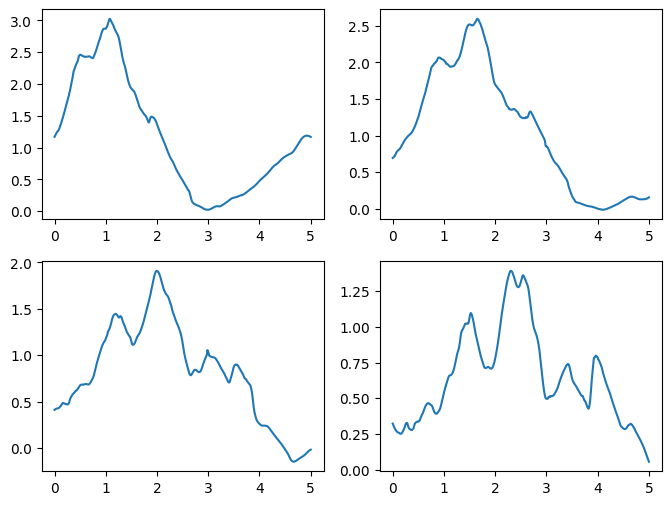

In [154]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6))

ax[0, 0].plot(color_df.index, color_df['g-r'])
ax[0, 1].plot(color_df.index, color_df['r-i'])
ax[1, 0].plot(color_df.index, color_df['i-z'])
ax[1, 1].plot(color_df.index, color_df['z-y'])

Text(0.5, 0, 'y')

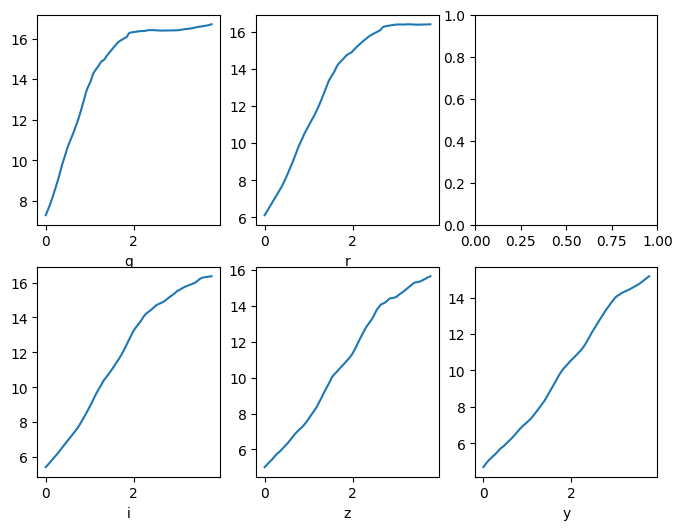

In [168]:

fig, ax = plt.subplots(2, 3, figsize=(8, 6))

ax[0, 0].plot(phot_s_df.T.index, phot_s_df.T['hsc_g'])
ax[0,0].set_xlabel('g')
ax[0, 1].plot(phot_s_df.T.index, phot_s_df.T['hsc_r'])
ax[0, 1].set_xlabel('r')
ax[1, 0].plot(phot_s_df.T.index, phot_s_df.T['hsc_i'])
ax[1, 0].set_xlabel('i')
ax[1, 1].plot(phot_s_df.T.index, phot_s_df.T['hsc_z'])
ax[1,1].set_xlabel('z')
ax[1, 2].plot(phot_s_df.T.index, phot_s_df.T['hsc_y'])
ax[1,2].set_xlabel('y')

Text(0.5, 0, 'y')

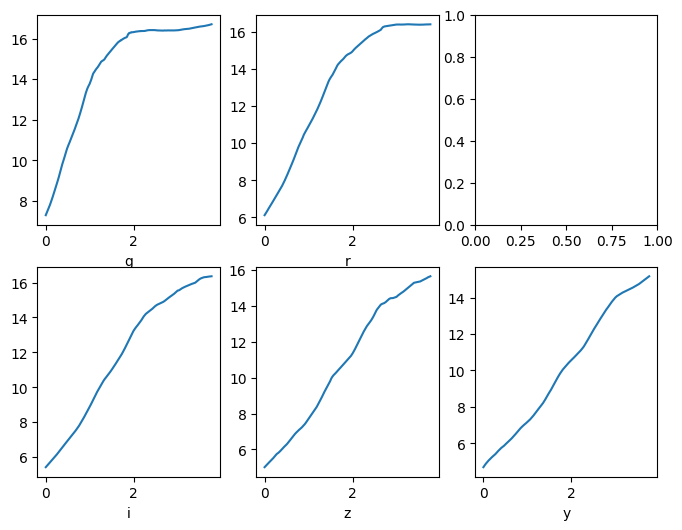

In [170]:
fig, ax = plt.subplots(2, 3, figsize=(8, 6))

ax[0, 0].plot(phot_noisy_df.T.index, phot_noisy_df.T['hsc_g'])
ax[0,0].set_xlabel('g')
ax[0, 1].plot(phot_noisy_df.T.index, phot_noisy_df.T['hsc_r'])
ax[0, 1].set_xlabel('r')
ax[1, 0].plot(phot_noisy_df.T.index, phot_noisy_df.T['hsc_i'])
ax[1, 0].set_xlabel('i')
ax[1, 1].plot(phot_noisy_df.T.index, phot_noisy_df.T['hsc_z'])
ax[1,1].set_xlabel('z')
ax[1, 2].plot(phot_noisy_df.T.index, phot_noisy_df.T['hsc_y'])
ax[1,2].set_xlabel('y')

In [221]:
from scipy.interpolate import InterpolatedUnivariateSpline, interp1d


# Approximate luminosity distance for flat LCDM
def DL(z):
    return np.exp(30.5 * z**0.04 - 21.7)

# We will now use the BPZ routines to load the magnitude-redshift model for each template.
# We'll have interpolated and discretized versions
nf = len(filters)
nz = len(z_grid)
f_mod = np.zeros((nz,nt,nf))*0.
f_mod_interps = np.zeros((nt, nf), dtype=interp1d)
lambdaRef = 4.5e3
for it in range(nt):
    seddata = np.genfromtxt('default_sed1.dat')
    seddata[:, 1] *= seddata[:, 0]**2. / 3e18
    ref = np.interp(lambdaRef, seddata[:, 0], seddata[:, 1])
    seddata[:, 1] /= ref
    sed_interp = interp1d(seddata[:, 0], seddata[:, 1], kind='linear', bounds_error=False, fill_value=0.0, assume_sorted=False)
    for jf in range(nf):
        data = np.genfromtxt(fn[jf] + '.dat')
        xf, yf = data[:, 0], data[:, 1]
        yf /= xf  # divide by lambda
        # Only consider range where >1% max
        ind = np.where(yf > 0.01*np.nanmax(yf))[0]
        lambdaMin, lambdaMax = xf[ind[0]], xf[ind[-1]]
        norm = np.trapz(yf[1:], x=xf[1:])
        for iz in range(z_grid.size):
            opz = (z_grid[iz] + 1)
            xf_z = np.linspace(lambdaMin / opz, lambdaMax / opz, num=5000)
            yf_z = interp1d(xf / opz, yf)(xf_z)
            ysed = sed_interp(xf_z)
            f_mod[iz, it, jf] = np.trapz(ysed * yf_z, x=xf_z) / norm
            f_mod[iz, it, jf] *= opz**2. / DL(z_grid[iz])**2. / (4*np.pi)
        f_mod_interps[it, jf] = InterpolatedUnivariateSpline(z_grid, f_mod[:, it, jf])

In [226]:
cmod=np.array([-2.5*np.log10(np.clip(
                        f_mod_interps[templatetypesnb,jf](redshifts[i]))) for i in range(len(redshifts))])

IndexError: index 1 is out of bounds for axis 0 with size 1